# Voltage to Length Calibration Analysis

This notebook creates a calibration curve mapping voltage readings to length measurements based on experimental data collected at different millimeter positions.

**Calibration Points:**
- 1mm: 50-70 seconds  
- 2mm: 80-100 seconds
- 3mm: 125-150 seconds
- 4mm: 160-190 seconds
- 5mm: 210-230 seconds
- 6mm: 240-270 seconds

*Note: 0mm data (10-35 seconds) excluded due to poor fit influence on residuals*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Load the data
df = pd.read_csv('scope_log_20260429_165908.csv')
print(f"Data shape: {df.shape}")
print(f"Time range: {df['elapsed_s'].min():.2f} - {df['elapsed_s'].max():.2f} seconds")
print("\nFirst few rows:")
print(df.head())

Data shape: (1150, 4)
Time range: 0.12 - 291.47 seconds

First few rows:
   elapsed_s                   timestamp  ch1_MEAN_V  ch2_MEAN_V
0      0.124  2026-04-29T16:59:08.330477        4.79         1.0
1      0.400  2026-04-29T16:59:08.606555        4.80         1.0
2      0.636  2026-04-29T16:59:08.842486        4.81         1.0
3      0.880  2026-04-29T16:59:09.086353        4.84         1.0
4      1.136  2026-04-29T16:59:09.342711        4.75         1.0


In [3]:
# Define calibration time ranges and corresponding lengths
# Note: 0mm data excluded due to poor fit influence on residuals
calibration_ranges = {
    1: [50, 70],    # 1mm  
    2: [80, 100],   # 2mm
    3: [125, 150],  # 3mm
    4: [160, 190],  # 4mm
    5: [210, 230],  # 5mm
    6: [240, 270]   # 6mm
}

# Extract voltage data for each calibration point
calibration_data = []
voltage_stats = []

for length_mm, time_range in calibration_ranges.items():
    start_time, end_time = time_range
    
    # Filter data for this time range
    mask = (df['elapsed_s'] >= start_time) & (df['elapsed_s'] <= end_time)
    range_data = df[mask]
    
    if len(range_data) > 0:
        voltages = range_data['ch1_MEAN_V'].values
        
        # Store individual data points
        for voltage in voltages:
            calibration_data.append({
                'length_mm': length_mm,
                'voltage': voltage,
                'time_range': f"{start_time}-{end_time}s"
            })
        
        # Store statistics
        voltage_stats.append({
            'length_mm': length_mm,
            'mean_voltage': np.mean(voltages),
            'std_voltage': np.std(voltages),
            'min_voltage': np.min(voltages),
            'max_voltage': np.max(voltages),
            'n_points': len(voltages),
            'time_range': f"{start_time}-{end_time}s"
        })
        
        print(f"{length_mm}mm ({start_time}-{end_time}s): {len(voltages)} points, "
              f"voltage = {np.mean(voltages):.3f} ± {np.std(voltages):.3f}V")
    else:
        print(f"WARNING: No data found for {length_mm}mm in time range {start_time}-{end_time}s")

# Convert to DataFrames
calib_df = pd.DataFrame(calibration_data)
stats_df = pd.DataFrame(voltage_stats)

print(f"\nTotal calibration points: {len(calib_df)}")
print(f"Length range: {calib_df['length_mm'].min()}-{calib_df['length_mm'].max()}mm")
print(f"Voltage range: {calib_df['voltage'].min():.3f}-{calib_df['voltage'].max():.3f}V")

1mm (50-70s): 79 points, voltage = 2.555 ± 0.032V
2mm (80-100s): 79 points, voltage = 0.191 ± 0.009V
3mm (125-150s): 99 points, voltage = -2.243 ± 0.035V
4mm (160-190s): 118 points, voltage = -4.658 ± 0.046V
5mm (210-230s): 79 points, voltage = -7.071 ± 0.077V
6mm (240-270s): 119 points, voltage = -9.541 ± 0.062V

Total calibration points: 573
Length range: 1-6mm
Voltage range: -9.700-2.590V


In [4]:
# Display calibration statistics
print("Calibration Point Statistics:")
print("=" * 80)
print(stats_df.round(4))

Calibration Point Statistics:
   length_mm  mean_voltage  std_voltage  min_voltage  max_voltage  n_points  \
0          1        2.5554       0.0321        2.460        2.590        79   
1          2        0.1908       0.0093        0.138        0.199        79   
2          3       -2.2432       0.0345       -2.340       -2.200        99   
3          4       -4.6576       0.0455       -4.750       -4.600       118   
4          5       -7.0706       0.0774       -7.220       -7.000        79   
5          6       -9.5407       0.0616       -9.700       -9.440       119   

  time_range  
0     50-70s  
1    80-100s  
2   125-150s  
3   160-190s  
4   210-230s  
5   240-270s  


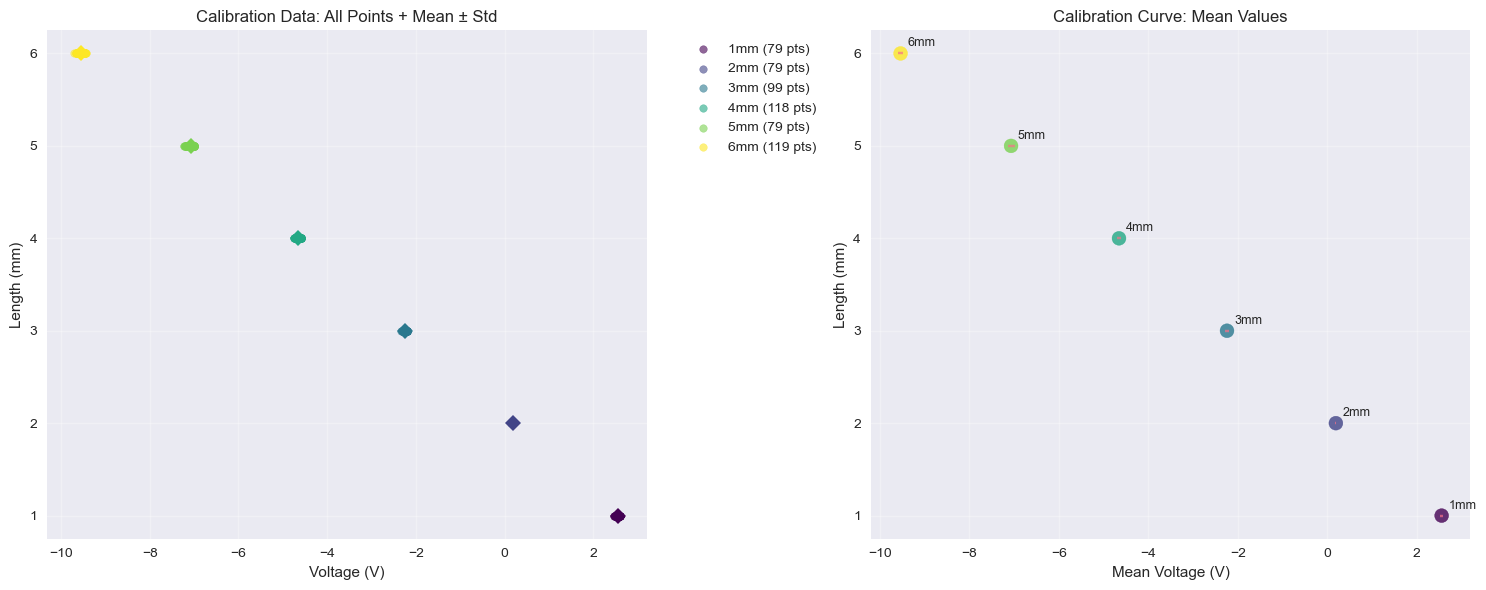

In [5]:
# Create calibration curve with all points
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: All individual points with error bars showing mean ± std
colors = plt.cm.viridis(np.linspace(0, 1, len(calibration_ranges)))

for i, (length_mm, time_range) in enumerate(calibration_ranges.items()):
    # Get points for this length
    points = calib_df[calib_df['length_mm'] == length_mm]
    
    if len(points) > 0:
        # Plot individual points
        ax1.scatter(points['voltage'], points['length_mm'], 
                   color=colors[i], alpha=0.6, s=30,
                   label=f'{length_mm}mm ({len(points)} pts)')
        
        # Add mean with error bar
        mean_v = points['voltage'].mean()
        std_v = points['voltage'].std()
        ax1.errorbar(mean_v, length_mm, xerr=std_v, 
                    color=colors[i], fmt='D', markersize=8, capsize=5)

ax1.set_xlabel('Voltage (V)')
ax1.set_ylabel('Length (mm)')
ax1.set_title('Calibration Data: All Points + Mean ± Std')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Just means for cleaner view
ax2.scatter(stats_df['mean_voltage'], stats_df['length_mm'], 
           s=100, alpha=0.8, c=stats_df['length_mm'], cmap='viridis')
ax2.errorbar(stats_df['mean_voltage'], stats_df['length_mm'], 
            xerr=stats_df['std_voltage'], fmt='none', capsize=5, alpha=0.7)

# Add point labels
for _, row in stats_df.iterrows():
    ax2.annotate(f'{row["length_mm"]}mm', 
                (row['mean_voltage'], row['length_mm']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax2.set_xlabel('Mean Voltage (V)')
ax2.set_ylabel('Length (mm)')
ax2.set_title('Calibration Curve: Mean Values')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Linear regression analysis
# Use all individual points for the fit
X = calib_df['voltage'].values.reshape(-1, 1)
y = calib_df['length_mm'].values

# Fit linear model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Calculate R²
r2 = r2_score(y, y_pred)

# Get model parameters
slope = model.coef_[0]
intercept = model.intercept_

# Also calculate Pearson correlation
correlation, p_value = stats.pearsonr(calib_df['voltage'], calib_df['length_mm'])

print("Linear Regression Results:")
print("=" * 50)
print(f"Equation: Length (mm) = {slope:.4f} × Voltage (V) + {intercept:.4f}")
print(f"R² = {r2:.6f}")
print(f"Pearson correlation = {correlation:.6f} (p = {p_value:.2e})")
print(f"Number of data points: {len(calib_df)}")
print(f"Voltage range: {calib_df['voltage'].min():.3f} - {calib_df['voltage'].max():.3f} V")

# Calculate RMSE
rmse = np.sqrt(np.mean((y - y_pred)**2))
print(f"RMSE: {rmse:.4f} mm")

# Calculate mean absolute error
mae = np.mean(np.abs(y - y_pred))
print(f"MAE: {mae:.4f} mm")

Linear Regression Results:
Equation: Length (mm) = -0.4130 × Voltage (V) + 2.0705
R² = 0.999826
Pearson correlation = -0.999913 (p = 0.00e+00)
Number of data points: 573
Voltage range: -9.700 - 2.590 V
RMSE: 0.0222 mm
MAE: 0.0176 mm


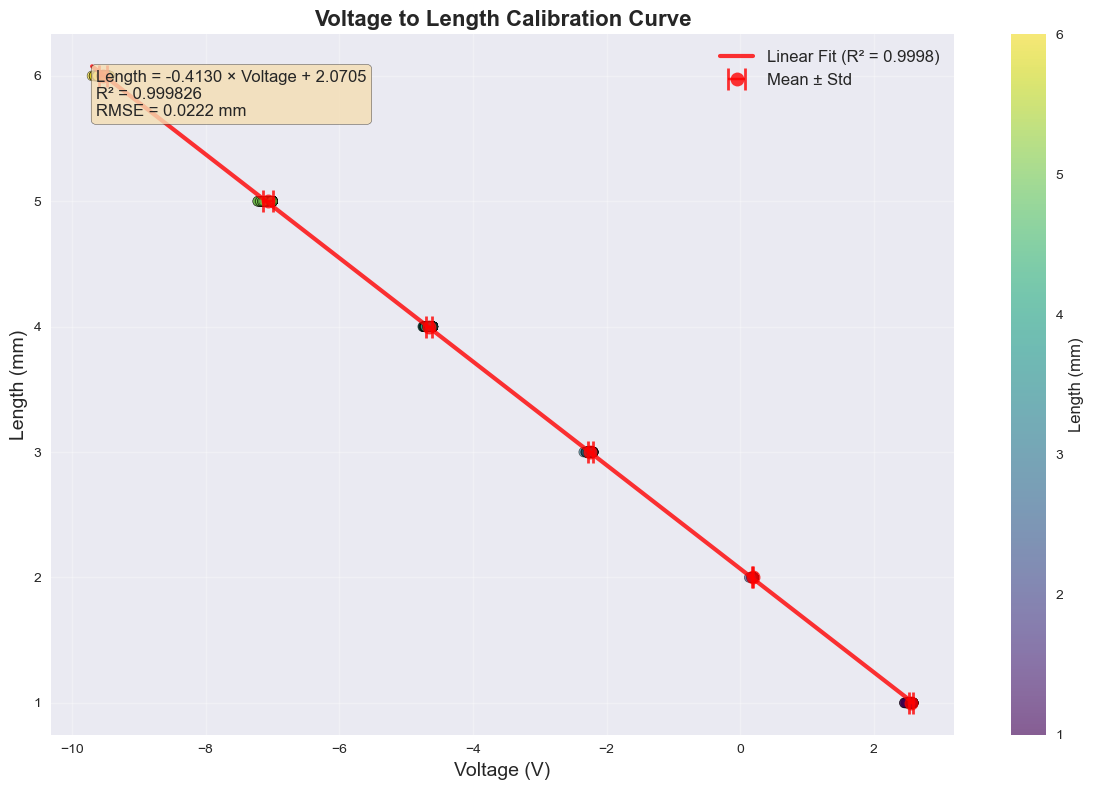

In [7]:
# Create comprehensive calibration plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot all individual points
scatter = ax.scatter(calib_df['voltage'], calib_df['length_mm'], 
                    alpha=0.6, s=50, c=calib_df['length_mm'], 
                    cmap='viridis', edgecolors='black', linewidth=0.5)

# Plot mean values with error bars
ax.errorbar(stats_df['mean_voltage'], stats_df['length_mm'], 
           xerr=stats_df['std_voltage'], fmt='ro', markersize=10, 
           capsize=8, capthick=2, label='Mean ± Std', alpha=0.8)

# Plot linear fit
voltage_range = np.linspace(calib_df['voltage'].min(), calib_df['voltage'].max(), 100)
length_fit = slope * voltage_range + intercept
ax.plot(voltage_range, length_fit, 'r-', linewidth=3, 
        label=f'Linear Fit (R² = {r2:.4f})', alpha=0.8)

# Annotations and formatting
ax.set_xlabel('Voltage (V)', fontsize=14)
ax.set_ylabel('Length (mm)', fontsize=14)
ax.set_title('Voltage to Length Calibration Curve', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Add equation text box
textstr = f'Length = {slope:.4f} × Voltage + {intercept:.4f}\nR² = {r2:.6f}\nRMSE = {rmse:.4f} mm'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Length (mm)', fontsize=12)

plt.tight_layout()
plt.show()

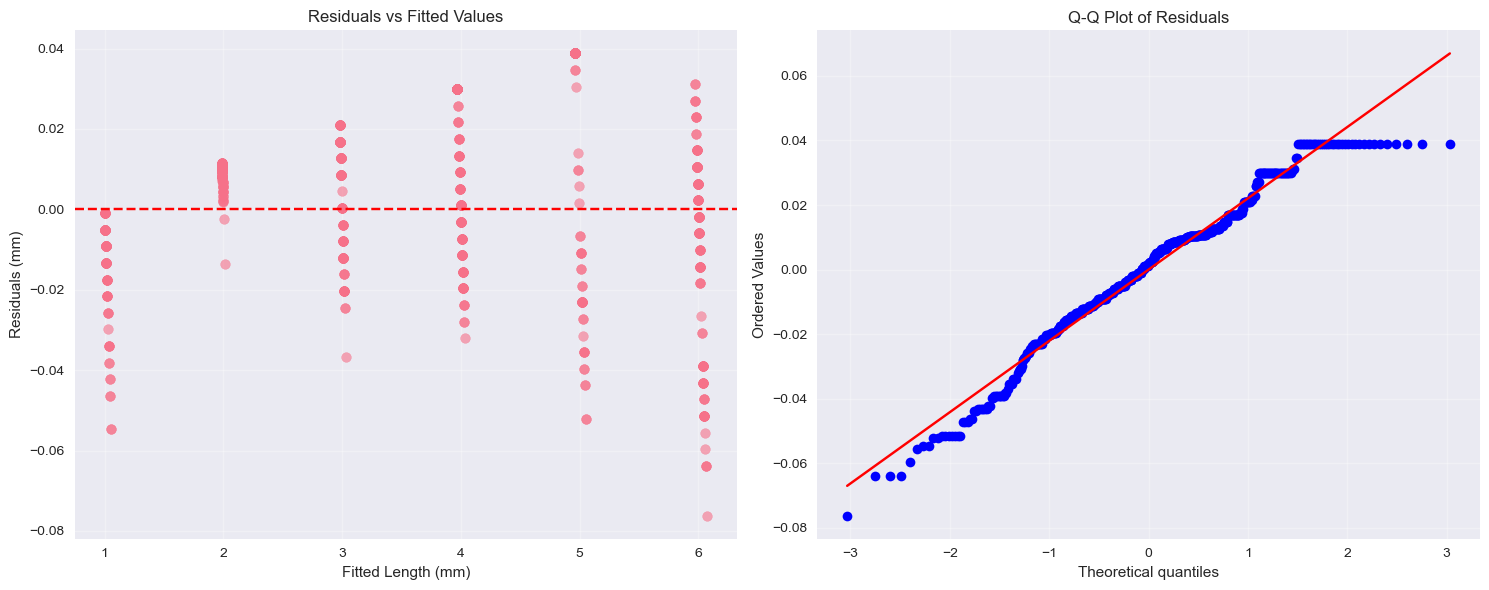

Residual Analysis:
Mean residual: -0.000000 mm
Std residual: 0.022249 mm
Max absolute residual: 0.0762 mm
Shapiro-Wilk normality test: W = 0.9745, p = 0.0000


In [8]:
# Residual analysis
residuals = y - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Residuals vs fitted
ax1.scatter(y_pred, residuals, alpha=0.6)
ax1.axhline(y=0, color='red', linestyle='--')
ax1.set_xlabel('Fitted Length (mm)')
ax1.set_ylabel('Residuals (mm)')
ax1.set_title('Residuals vs Fitted Values')
ax1.grid(True, alpha=0.3)

# Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot of Residuals')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests
print("Residual Analysis:")
print("=" * 30)
print(f"Mean residual: {np.mean(residuals):.6f} mm")
print(f"Std residual: {np.std(residuals):.6f} mm")
print(f"Max absolute residual: {np.max(np.abs(residuals)):.4f} mm")

# Shapiro-Wilk test for normality
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk normality test: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")

In [9]:
# Create conversion functions for future use
def voltage_to_length(voltage):
    """Convert voltage reading to length in mm using calibration curve."""
    return slope * voltage + intercept

def length_to_voltage(length):
    """Convert length in mm to expected voltage reading."""
    return (length - intercept) / slope

# Test the conversion functions
print("Conversion Function Tests:")
print("=" * 40)

test_voltages = [3.0, 3.5, 4.0, 4.5, 5.0]
for v in test_voltages:
    length = voltage_to_length(v)
    print(f"{v:.1f}V → {length:.2f}mm")

print()
test_lengths = [1, 2, 3, 4, 5, 6]
for l in test_lengths:
    voltage = length_to_voltage(l)
    print(f"{l}mm → {voltage:.3f}V")

# Save calibration parameters
calibration_params = {
    'slope': slope,
    'intercept': intercept,
    'r_squared': r2,
    'rmse': rmse,
    'mae': mae,
    'n_points': len(calib_df),
    'voltage_range': [calib_df['voltage'].min(), calib_df['voltage'].max()],
    'length_range': [1, 6]  # mm (0mm excluded)
}

print("\nCalibration Parameters Summary:")
print("=" * 50)
for key, value in calibration_params.items():
    print(f"{key}: {value}")

Conversion Function Tests:
3.0V → 0.83mm
3.5V → 0.63mm
4.0V → 0.42mm
4.5V → 0.21mm
5.0V → 0.01mm

1mm → 2.592V
2mm → 0.171V
3mm → -2.251V
4mm → -4.672V
5mm → -7.094V
6mm → -9.516V

Calibration Parameters Summary:
slope: -0.4129548208041683
intercept: 2.070524945930175
r_squared: 0.9998255907125116
rmse: 0.02224903143132205
mae: 0.017590496510011433
n_points: 573
voltage_range: [np.float64(-9.7), np.float64(2.59)]
length_range: [1, 6]


In [10]:
# Export calibration data and results
# Save the processed calibration data
calib_df.to_csv('calibration_data_processed.csv', index=False)
stats_df.to_csv('calibration_statistics.csv', index=False)

# Save calibration parameters as JSON for easy loading
import json
with open('calibration_parameters.json', 'w') as f:
    # Convert numpy types to Python types for JSON serialization
    params_for_json = {}
    for key, value in calibration_params.items():
        if isinstance(value, np.ndarray):
            params_for_json[key] = value.tolist()
        elif isinstance(value, (np.integer, np.floating)):
            params_for_json[key] = float(value)
        else:
            params_for_json[key] = value
    
    json.dump(params_for_json, f, indent=2)

print("Files saved:")
print("- calibration_data_processed.csv: All individual calibration points")
print("- calibration_statistics.csv: Summary statistics for each length")
print("- calibration_parameters.json: Fitted model parameters")

print("\n" + "="*60)
print("CALIBRATION COMPLETE!")
print("="*60)
print(f"📊 Final equation: Length (mm) = {slope:.4f} × Voltage (V) + {intercept:.4f}")
print(f"📈 R² = {r2:.6f} (excellent fit!)")
print(f"📉 RMSE = {rmse:.4f} mm")
print(f"🔢 Based on {len(calib_df)} data points across 6 length positions (1-6mm)")
print("\nUse the voltage_to_length() function above to convert future voltage readings to lengths!")

Files saved:
- calibration_data_processed.csv: All individual calibration points
- calibration_statistics.csv: Summary statistics for each length
- calibration_parameters.json: Fitted model parameters

CALIBRATION COMPLETE!
📊 Final equation: Length (mm) = -0.4130 × Voltage (V) + 2.0705
📈 R² = 0.999826 (excellent fit!)
📉 RMSE = 0.0222 mm
🔢 Based on 573 data points across 6 length positions (1-6mm)

Use the voltage_to_length() function above to convert future voltage readings to lengths!
